# Explainable Machine Learning for Heart Disease Prediction

### A Comparative Analysis of Logistic Regression, Random Forest, and XGBoost

**Bachelor's Thesis Implementation Notebook**

---


**Author:** Negin Hezarjaribi

**Degree Programme:** B.Sc. Applied Artificial Intelligence

**University:** IU International University of Applied Sciences

# 1. Notebook Overview

This notebook contains the complete implementation accompanying the bachelor's thesis. It follows the experimental workflow described in the thesis, including:

- Data preprocessing
- Exploratory data analysis
- Logistic Regression
- Random Forest
- XGBoost
- SHAP-based explainability
- Supplementary evaluation using the Statlog Heart Disease dataset

# 2. Import Libraries

Import the required Python libraries for data analysis, machine learning, data visualization, and model explainability.

In [1]:
!pip install -q shap

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import shap

# 3. Dataset Loading

Load the Cleveland Heart Disease dataset and assign descriptive column names.

In [3]:
columns = [
    'age',
    'sex',
    'cp',
    'trestbps',
    'chol',
    'fbs',
    'restecg',
    'thalach',
    'exang',
    'oldpeak',
    'slope',
    'ca',
    'thal',
    'target'
]

In [4]:
df = pd.read_csv(
    "processed.cleveland.data",
    header=None,
    names=columns
)

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


# 4. Dataset Understanding

Explore the structure of the dataset before any preprocessing is applied.

In [6]:
df.shape

(303, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [8]:
df.isin(['?']).sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


The original dataset contains 303 patient records and 14 variables. Initial inspection shows that the features `ca` and `thal` contain missing values represented by the symbol `?`.

# 5. Data Preprocessing

## 5.1 Missing Value Handling

Replace missing value indicators with NaN and remove incomplete records.

In [9]:
df.replace('?', np.nan, inplace=True)

In [10]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [11]:
df = df.dropna()

In [12]:
df = df.reset_index(drop=True)

Only six observations contained missing values (four in `ca` and two in `thal`). Since these represented less than 2% of the dataset, complete-case deletion was applied. The dataset size was reduced from 303 to 297 observations.

## 5.2 Data Type Conversion

Convert the remaining object-type variables, `ca` and `thal`, into numeric format after removing the missing-value indicators.

In [13]:
df.shape

(297, 14)

In [14]:
df['ca'] = pd.to_numeric(df['ca'])
df['thal'] = pd.to_numeric(df['thal'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  target    297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 32.6 KB


## 5.3 Target Transformation

Convert the original five-class target variable into a binary classification problem.

In [16]:
df['target'].value_counts()

,count
target,
0,160
1,54
2,35
3,35
4,13


The original target variable ranges from 0 to 4, where 0 represents the absence of heart disease and values from 1 to 4 indicate its presence.

Since this study focuses on binary heart disease prediction, all values greater than zero were converted into a single positive class.

In [17]:
df['target'] = (df['target'] > 0).astype(int)

In [18]:
df['target'].value_counts()

,count
target,
0,160
1,137


In [19]:
df['target'].value_counts(normalize=True)*100

,proportion
target,
0,53.872054
1,46.127946


After transformation, the dataset contains 160 patients without heart disease (53.9%) and 137 patients with heart disease (46.1%). The class distribution is relatively balanced; therefore, no additional resampling techniques were applied.

# 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was conducted to examine the characteristics of the cleaned dataset before model development. The analysis included descriptive statistics, target and feature distributions, and an exploratory correlation matrix.

The analysis was descriptive and was not intended to establish predictive, clinical, or causal relationships between the variables and the target outcome.

## 6.1 Descriptive Statistics

Descriptive statistics were generated to summarise the numerical variables, including their central tendency, variability, and observed ranges.

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,297.0,54.542088,9.049736,29.0,48.0,56.0,61.0,77.0
sex,297.0,0.676768,0.468500,0.0,0.0,1.0,1.0,1.0
cp,297.0,3.158249,0.964859,1.0,3.0,3.0,4.0,4.0
trestbps,297.0,131.693603,17.762806,94.0,120.0,130.0,140.0,200.0
chol,297.0,247.350168,51.997583,126.0,211.0,243.0,276.0,564.0
fbs,297.0,0.144781,0.352474,0.0,0.0,0.0,0.0,1.0
restecg,297.0,0.996633,0.994914,0.0,0.0,1.0,2.0,2.0
thalach,297.0,149.599327,22.941562,71.0,133.0,153.0,166.0,202.0
exang,297.0,0.326599,0.469761,0.0,0.0,0.0,1.0,1.0
oldpeak,297.0,1.055556,1.166123,0.0,0.0,0.8,1.6,6.2


## 6.2 Target Distribution

The distribution of the binary target variable was examined to determine whether either class was substantially underrepresented.

In [21]:
df['target'].value_counts()

,count
target,
0,160
1,137


In [22]:
df['target'].value_counts(normalize=True) * 100

,proportion
target,
0,53.872054
1,46.127946


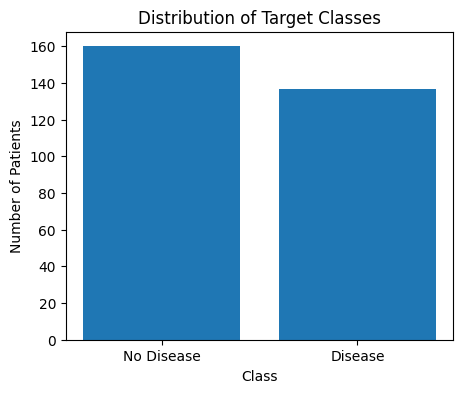

In [23]:
target_counts = df['target'].value_counts().sort_index()

plt.figure(figsize=(5,4))
plt.bar(
    ['No Disease', 'Disease'],
    target_counts.values
)

plt.title('Distribution of Target Classes')
plt.xlabel('Class')
plt.ylabel('Number of Patients')

plt.show()

### Interpretation

The binary target variable contains 160 observations (53.9%) in the no-heart-disease class and 137 observations (46.1%) in the heart-disease class. The class distribution is relatively balanced; therefore, no additional class-balancing technique was applied.

## 6.3 Age Distribution

The age distribution was examined to describe the demographic composition of the study population and to identify the observed age range before model development.

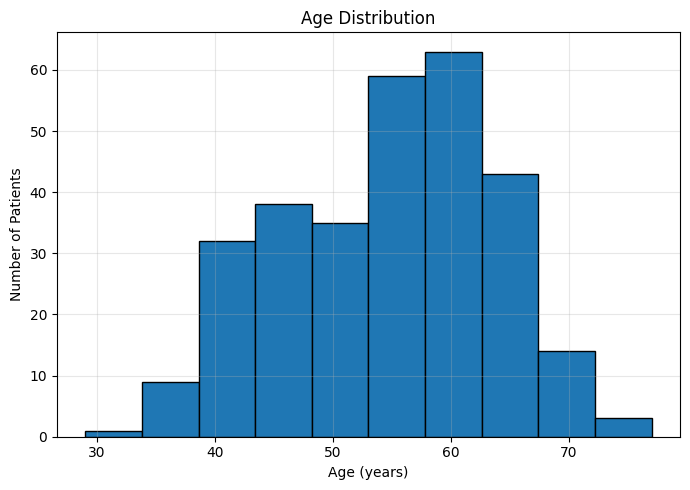

In [24]:
plt.figure(figsize=(7,5))

plt.hist(df['age'], bins=10, edgecolor='black')

plt.title('Age Distribution')
plt.xlabel('Age (years)')
plt.ylabel('Number of Patients')

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation

Patient age ranged from 29 to 77 years, with a mean of 54.5 years and a median of 56 years. The interquartile range extended from 48 to 61 years, indicating that most observations were concentrated among middle-aged and older adults.

The distribution was approximately unimodal, and no clearly implausible age values were identified.

### Key Finding

The dataset primarily represents middle-aged and older adults, with most observations concentrated between 48 and 61 years.

## 6.4 Sex Distribution

The distribution of patient sex was examined to describe the demographic composition of the cleaned dataset.

In [25]:
df['sex'].value_counts()

,count
sex,
1.0,201
0.0,96


In [26]:
df['sex'].value_counts(normalize=True) * 100

,proportion
sex,
1.0,67.676768
0.0,32.323232


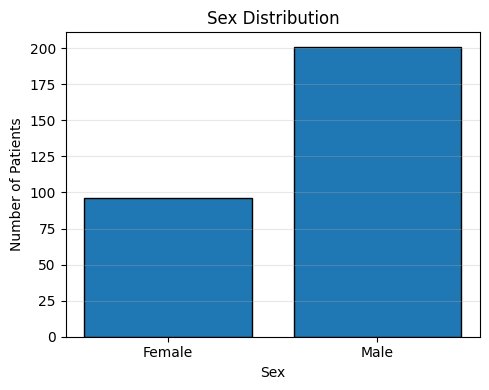

In [27]:
sex_counts = df['sex'].value_counts().sort_index()

plt.figure(figsize=(5,4))

plt.bar(
    ['Female', 'Male'],
    sex_counts.values,
    edgecolor='black'
)

plt.title('Sex Distribution')
plt.xlabel('Sex')
plt.ylabel('Number of Patients')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation

The dataset contains 201 male patients (67.7%) and 96 female patients (32.3%). Male patients therefore represent approximately two-thirds of the study population.

This distribution reflects the composition of the processed Cleveland dataset rather than a preprocessing decision. The contribution of sex to model predictions was examined later through the machine learning models and SHAP analysis.

### Key Finding

Male patients constitute 67.7% of the cleaned dataset.

## 6.5 Clinical Feature Distributions

This section examines selected continuous clinical variables with relatively wide numerical ranges: resting blood pressure, serum cholesterol, maximum heart rate, and exercise-induced ST depression (`oldpeak`).

Their distributions were reviewed to describe central tendency, variability, skewness, and potentially unusual observations before model development. Binary, categorical, and ordinal variables were instead examined through their coded values and later through model-based explainability.

### 6.5.1 Resting Blood Pressure (`trestbps`)

Resting blood pressure was examined to describe its distribution and identify potentially unusual values before model development.

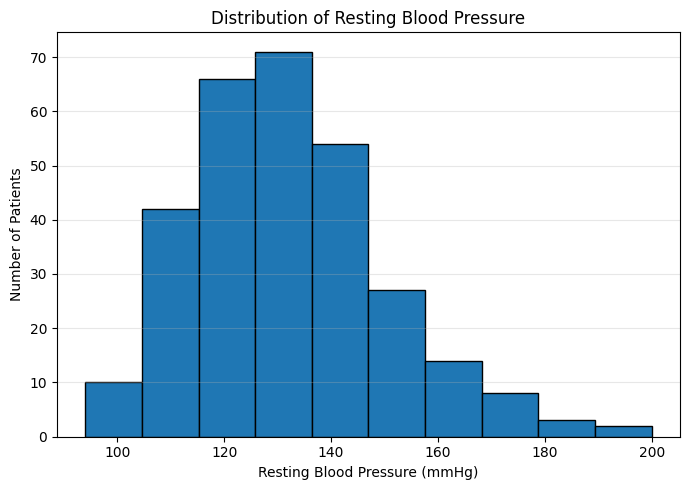

In [28]:
plt.figure(figsize=(7,5))

plt.hist(
    df['trestbps'],
    bins=10,
    edgecolor='black'
)

plt.title('Distribution of Resting Blood Pressure')
plt.xlabel('Resting Blood Pressure (mmHg)')
plt.ylabel('Number of Patients')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation

Resting blood pressure ranged from 94 to 200 mmHg, with a mean of 131.7 mmHg and a median of 130 mmHg. The distribution was unimodal and slightly right-skewed, with most observations concentrated between approximately 120 and 140 mmHg.

A small number of higher values were retained because they were not identified as data-entry errors.

### Key Finding

Resting blood pressure showed a slight positive skew, and the feature was retained without transformation.

### 6.5.2 Serum Cholesterol (`chol`)

Serum cholesterol was examined to describe its distribution, variability, and potentially extreme observations before model development.

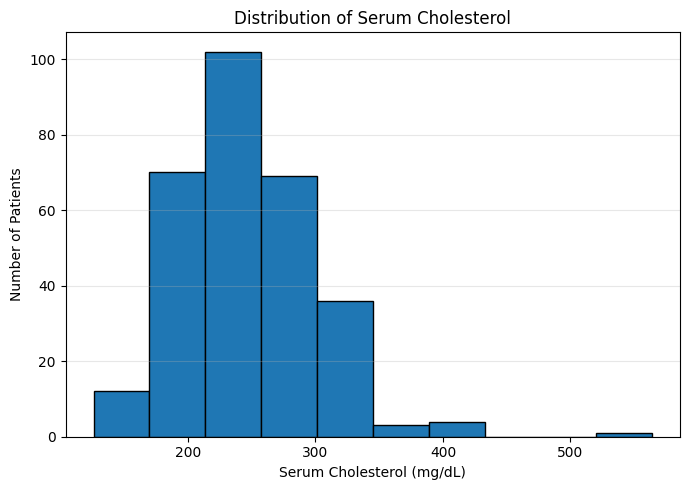

In [29]:
plt.figure(figsize=(7,5))

plt.hist(
    df['chol'],
    bins=10,
    edgecolor='black'
)

plt.title('Distribution of Serum Cholesterol')
plt.xlabel('Serum Cholesterol (mg/dL)')
plt.ylabel('Number of Patients')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation

Serum cholesterol ranged from 126 to 564 mg/dL, with a mean of 247.4 mg/dL and a median of 243 mg/dL. The distribution was positively skewed, with most observations concentrated between approximately 200 and 300 mg/dL.

A small number of substantially higher values were retained because they were not identified as data-entry errors.

### Key Finding

Serum cholesterol showed positive skewness and included several high observations, but no transformation was applied.

### Implication for Model Development

The observed distribution does not indicate a need for immediate preprocessing beyond the steps already performed. Although several relatively high cholesterol values are present, they may represent clinically valid observations rather than data errors. Therefore, the feature will be retained in its original form and evaluated further during model training and explainability analysis.

### 6.5.3 Maximum Heart Rate (`thalach`)

Maximum heart rate was examined to describe its distribution and identify potentially unusual observations before model development.

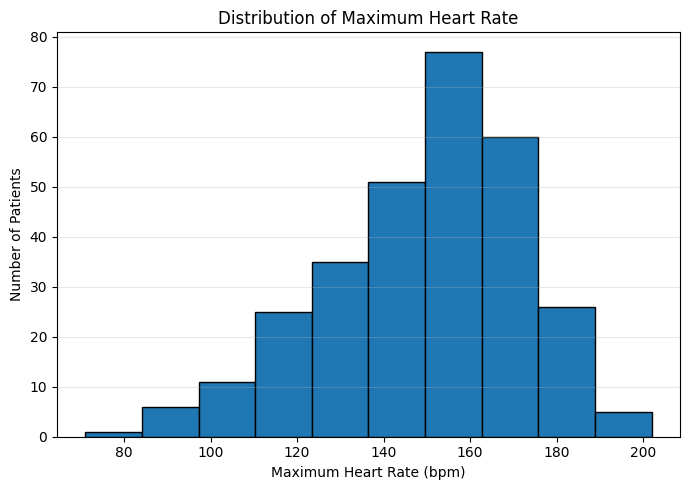

In [30]:
plt.figure(figsize=(7,5))

plt.hist(
    df['thalach'],
    bins=10,
    edgecolor='black'
)

plt.title('Distribution of Maximum Heart Rate')
plt.xlabel('Maximum Heart Rate (bpm)')
plt.ylabel('Number of Patients')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation

Maximum heart rate ranged from 71 to 202 beats per minute, with a mean of 149.6 bpm and a median of 153 bpm. The distribution was approximately unimodal with a slight negative skew, and no clearly implausible observations were identified.

### Key Finding

Maximum heart rate exhibits an approximately unimodal distribution with a slight negative skew. No transformation was applied before model development.

### Implication for Model Development

The feature was retained in its original form for all three machine learning models.

### 6.5.4 Exercise-Induced ST Depression (`oldpeak`)

Exercise-induced ST depression was examined to describe its distribution and identify skewness or unusual observations before model development.

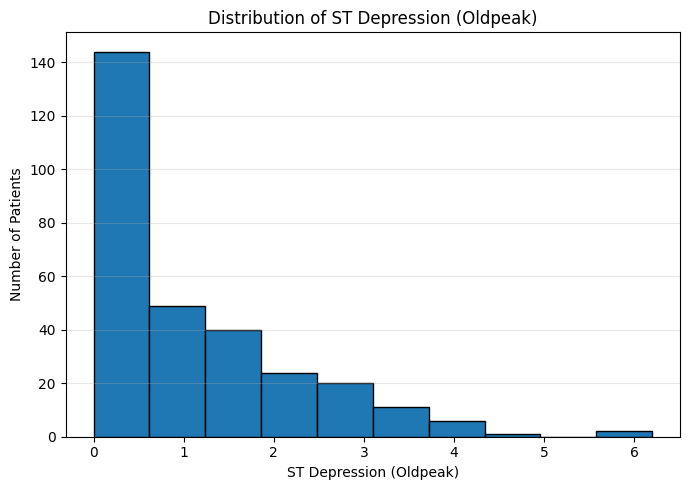

In [31]:
plt.figure(figsize=(7,5))

plt.hist(
    df['oldpeak'],
    bins=10,
    edgecolor='black'
)

plt.title('Distribution of ST Depression (Oldpeak)')
plt.xlabel('ST Depression (Oldpeak)')
plt.ylabel('Number of Patients')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()


plt.show()

### Interpretation

Exercise-induced ST depression ranged from 0.0 to 6.2, with a mean of 1.06 and a median of 0.8. The distribution was strongly right-skewed, with most observations concentrated at relatively low values and a small number forming a long upper tail.

The higher observations were retained because they were not identified as data-entry errors.

### Key Finding

Exercise-induced ST depression showed strong positive skewness, but no transformation or observation removal was applied.

### Implication for Model Development

The feature was retained in its original form and evaluated during model training and SHAP analysis.

### Summary of Clinical Feature Distributions

The selected continuous variables showed different distributional characteristics. Resting blood pressure exhibited slight positive skewness, maximum heart rate was approximately unimodal with slight negative skewness, and serum cholesterol and exercise-induced ST depression showed positive skewness.

Several relatively high observations were retained because they were not identified as data-entry errors. No additional transformation or outlier removal was applied before model development.

## 6.6 Correlation Matrix

A Pearson correlation matrix was generated to provide an exploratory overview of pairwise linear associations among the numerically represented variables.

Because several predictors were binary, categorical, or ordinal variables represented using numerical codes, the resulting coefficients were interpreted cautiously. The matrix was used only as an exploratory tool and not as evidence of causality, clinical importance, or direct feature importance.

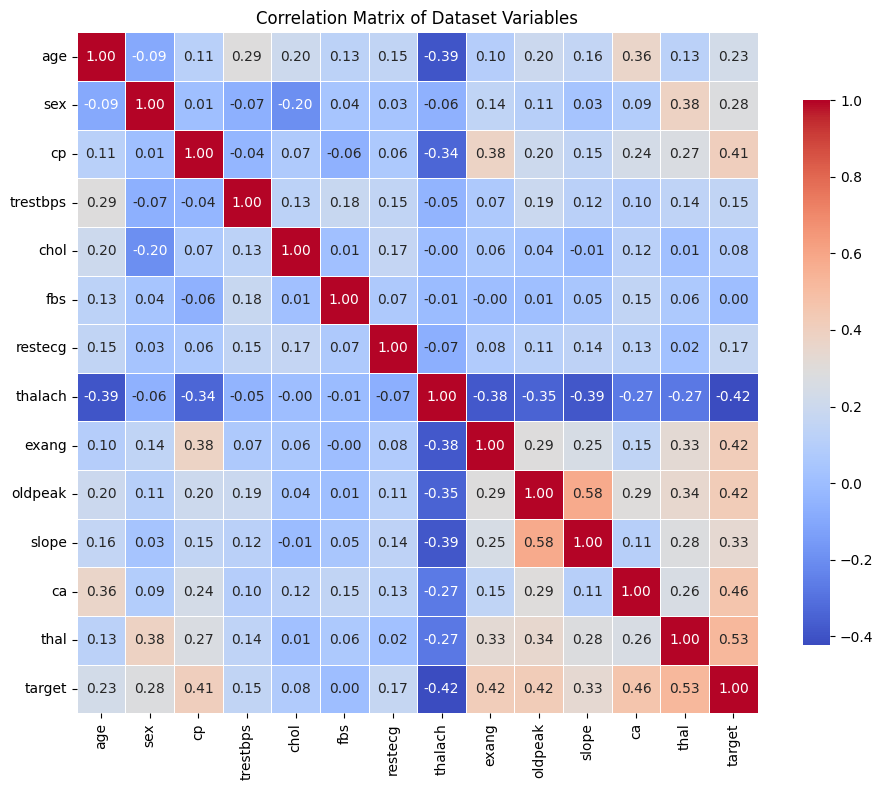

In [32]:
plt.figure(figsize=(10,8))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Dataset Variables")

plt.tight_layout()


plt.show()

The correlation matrix indicates that most predictor pairs exhibit weak to moderate linear associations. The strongest positive association among the predictors was observed between `oldpeak` and `slope` (r = 0.58). No predictor pair showed a very strong linear association.

With respect to the binary target, the largest positive correlations were observed for `thal` (r = 0.53), `ca` (r = 0.46), `exang` (r = 0.42), `oldpeak` (r = 0.42), and `cp` (r = 0.41), while `thalach` showed the strongest negative correlation (r = −0.42).

Because the matrix includes numerically encoded categorical and ordinal variables, these coefficients were not interpreted as direct measures of feature importance or causal relationships.

### Key Finding

Most predictor pairs exhibit weak to moderate linear associations, and no very strong pairwise correlations are observed. Therefore, no features were removed based solely on the correlation matrix.

### Implication for Model Development

No features were removed based on the exploratory correlation analysis. All predictor variables were retained for machine learning modelling, and their predictive contributions were evaluated later using model performance measures and SHAP explainability.

## 6.7 Summary of EDA Findings

The exploratory data analysis described the characteristics of the cleaned Cleveland Heart Disease dataset before model development. The dataset contained 297 observations and a relatively balanced binary target distribution. Most observations represented middle-aged and older adults, while male patients accounted for approximately two-thirds of the dataset.

The selected continuous variables showed different degrees of skewness, but no observations were removed or transformed solely on the basis of their distributions. The correlation matrix showed predominantly weak to moderate pairwise linear associations, and no predictor pair exhibited a very strong correlation.

Consequently, all 13 predictor variables were retained for machine learning model development and subsequent SHAP-based explainability analysis.

# 7. Data Preparation for Machine Learning

After completing the exploratory data analysis, the cleaned dataset was prepared for machine learning model development.

This stage included separating the predictor variables from the target variable, creating stratified training and testing subsets, and applying feature scaling where required. These procedures were used to ensure a consistent and reproducible experimental workflow.

## 7.1 Feature and Target Separation

The cleaned dataset was separated into the feature matrix (`X`) and the target vector (`y`). The feature matrix contained the 13 demographic and clinical predictor variables, while the target vector represented the binary absence or presence of heart disease.

In [33]:
X = df.drop(columns='target')

y = df['target']

In [34]:
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (297, 13)
Target vector shape: (297,)


### Interpretation

The resulting feature matrix contained 297 observations and 13 predictor variables, while the target vector contained 297 corresponding binary class labels.

### Key Finding

The dataset was correctly structured for supervised binary classification.

### Implication for Model Development

The same feature matrix and target vector were used throughout the subsequent model-development workflow.

## 7.2 Train-Test Split

The cleaned dataset was divided into training and testing subsets using an 80:20 stratified train-test split. The training subset was used for model fitting, while the testing subset was reserved for performance evaluation on previously unseen observations.

Stratification preserved the class distribution of the binary target variable in both subsets. A fixed random state of 42 was specified to improve reproducibility.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [36]:
print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (237, 13)
Testing set : (60, 13)


In [37]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
target
0    54.008439
1    45.991561
Name: proportion, dtype: float64

Testing target distribution:
target
0    53.333333
1    46.666667
Name: proportion, dtype: float64


### Interpretation

The split produced 237 training observations and 60 testing observations. Stratification preserved similar proportions of the two target classes in both subsets.

### Key Finding

The training and testing subsets maintained the class distribution of the cleaned dataset.

### Implication for Model Development

The training subset was used exclusively for model fitting, while the testing subset was reserved for the comparative evaluation of all three models.

## 7.3 Feature Scaling

Feature scaling was applied only for Logistic Regression because its optimisation procedure is sensitive to differences in feature magnitude. Random Forest and XGBoost were trained using the original unscaled features because tree-based algorithms are generally unaffected by feature scaling.

To prevent data leakage, `StandardScaler` was fitted exclusively on the training data and then applied to both the training and testing subsets.

In [38]:
scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)

X_test_scaled = scaler.transform(X_test)

### Interpretation

`StandardScaler` was fitted only on the training subset and then used to transform both the training and testing data. This prevented the testing data from influencing the scaling parameters.

### Key Finding

Scaled features were prepared for Logistic Regression, while the original feature values were retained for Random Forest and XGBoost.

### Implication for Model Development

Each model was trained using the feature representation appropriate to its learning mechanism while preserving a consistent train-test split.

# 8. Model Development

Three supervised machine learning algorithms were developed and evaluated: Logistic Regression, Random Forest, and XGBoost.

Logistic Regression was trained using the scaled features, whereas Random Forest and XGBoost were trained using the original feature values. All three models were evaluated on the same testing dataset.

## 8.1 Experimental Setup

Three supervised machine learning algorithms were selected for this study: Logistic Regression, Random Forest, and XGBoost.

These models represent different machine learning approaches. Logistic Regression served as a linear baseline classifier, whereas Random Forest and XGBoost represented ensemble tree-based methods capable of modelling more complex, non-linear relationships.

To ensure a consistent comparison, all models were trained using the same training subset and evaluated using the same testing subset. The same classification metrics were applied to each model.

The models were implemented primarily using the default hyperparameter settings provided by their respective libraries. A fixed random state of 42 was specified where applicable to improve reproducibility. For XGBoost, the evaluation metric was set to log loss during training.

Hyperparameter optimisation was not performed because the primary objective was to compare the predictive behaviour and explainability of the three model families within a consistent experimental workflow rather than to maximise the performance of individual models through parameter tuning.

## 8.2 Logistic Regression

Logistic Regression was selected as the linear baseline model for binary classification. The model estimates the probability that an observation belongs to one of the two target classes.

Because Logistic Regression is sensitive to differences in feature magnitude, the scaled training and testing features were used for model development and evaluation.

### 8.2.1 Model Training and Prediction

The Logistic Regression model was fitted using the scaled training data. It was then used to generate predicted classes and positive-class probabilities for the testing subset.

In [39]:
lr_model = LogisticRegression(
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

### 8.2.2 Performance Metrics

Logistic Regression was evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. These complementary measures were used to assess classification performance at the selected decision threshold and discrimination across different thresholds.

In [40]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_prob_lr)

In [41]:
lr_results = pd.DataFrame({
    'Model': ['Logistic Regression'],
    'Accuracy': [lr_accuracy],
    'Precision': [lr_precision],
    'Recall': [lr_recall],
    'F1-score': [lr_f1],
    'ROC-AUC': [lr_roc_auc]
})

lr_results.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.833,0.846,0.786,0.815,0.95


### 8.2.3 Confusion Matrix

A confusion matrix was generated to summarise the true-negative, false-positive, false-negative, and true-positive predictions produced by Logistic Regression.

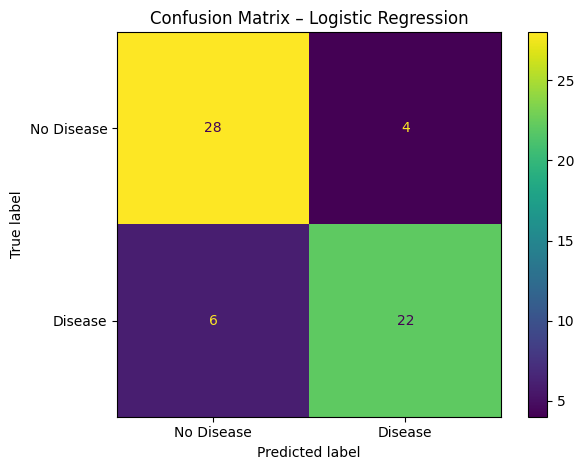

In [42]:
lr_confusion_matrix = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=lr_confusion_matrix,
    display_labels=['No Disease', 'Disease']
)

disp.plot(values_format='d')

plt.title('Confusion Matrix – Logistic Regression')
plt.tight_layout()


plt.show()

In [43]:
tn_lr, fp_lr, fn_lr, tp_lr = lr_confusion_matrix.ravel()

print("True Negatives :", tn_lr)
print("False Positives:", fp_lr)
print("False Negatives:", fn_lr)
print("True Positives :", tp_lr)

True Negatives : 28
False Positives: 4
False Negatives: 6
True Positives : 22


### 8.2.4 ROC Curve

The Receiver Operating Characteristic (ROC) curve was generated to examine the discrimination performance of Logistic Regression across different classification thresholds.

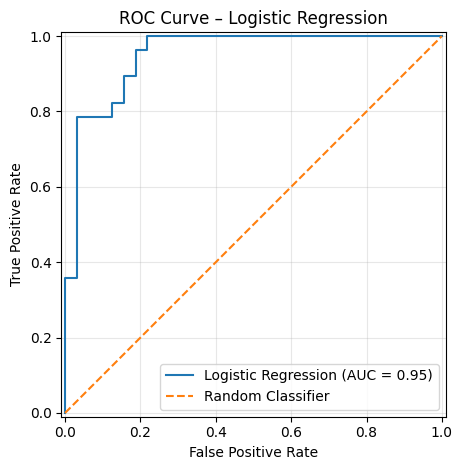

In [44]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name='Logistic Regression'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.title('ROC Curve – Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()


plt.show()

### 8.2.5 Model Interpretation

Logistic Regression achieved an accuracy of **83.3%**, a precision of **84.6%**, a recall of **78.6%**, and an F1-score of **81.5%**. Its ROC-AUC score was **0.950**.

The confusion matrix showed 28 true negatives, four false positives, six false negatives, and 22 true positives.

Overall, Logistic Regression provided a strong baseline and achieved the highest ROC-AUC among the three evaluated models. However, its accuracy, precision, and F1-score were lower than those obtained by Random Forest and XGBoost.

### Key Finding

Logistic Regression demonstrated the strongest ranking performance across classification thresholds, while providing competitive threshold-dependent classification results.

### Implication for Model Comparison

The Logistic Regression results provide the baseline for comparison with Random Forest and XGBoost using the same testing subset and evaluation metrics.

## 8.3 Random Forest

Random Forest was selected as an ensemble tree-based classifier capable of modelling non-linear relationships among the predictor variables.

Because tree-based models are generally unaffected by feature scaling, Random Forest was trained and evaluated using the original feature values.

### 8.3.1 Model Training and Prediction

The Random Forest model was fitted using the original training features. Predicted classes and positive-class probabilities were then generated for the testing subset.

In [45]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

### 8.3.2 Performance Metrics

Random Forest was evaluated using the same accuracy, precision, recall, F1-score, and ROC-AUC measures applied to Logistic Regression.

In [46]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

In [47]:
rf_results = pd.DataFrame({
    'Model': ['Random Forest'],
    'Accuracy': [rf_accuracy],
    'Precision': [rf_precision],
    'Recall': [rf_recall],
    'F1-score': [rf_f1],
    'ROC-AUC': [rf_roc_auc]
})

rf_results.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.85,0.88,0.786,0.83,0.941


### 8.3.3 Confusion Matrix

A confusion matrix was generated to summarise the classification outcomes produced by Random Forest.

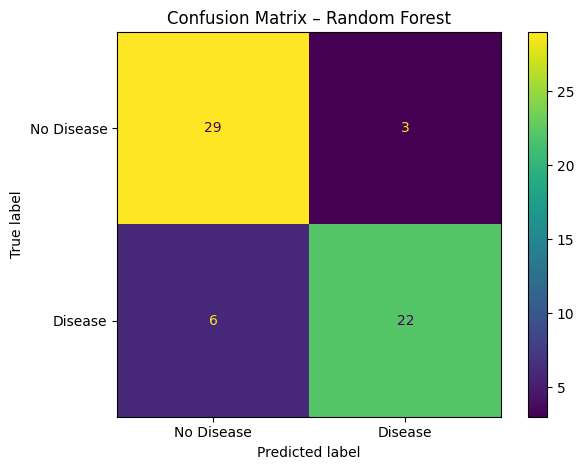

In [48]:
rf_confusion_matrix = confusion_matrix(
    y_test,
    y_pred_rf
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_confusion_matrix,
    display_labels=['No Disease', 'Disease']
)

disp.plot(values_format='d')

plt.title("Confusion Matrix – Random Forest")

plt.tight_layout()



plt.show()

### 8.3.4 ROC Curve

The ROC curve was generated to examine the discrimination performance of Random Forest across different classification thresholds.

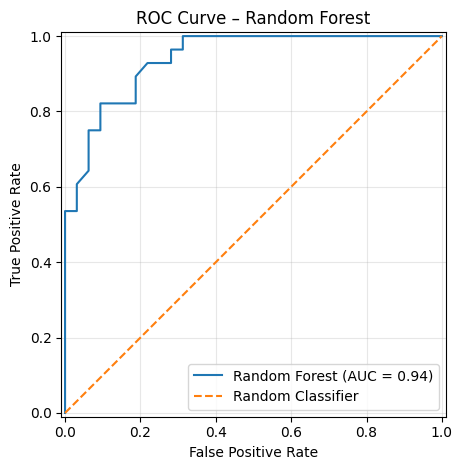

In [49]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve – Random Forest")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### 8.3.5 Model Interpretation

Random Forest achieved an accuracy of **85.0%**, a precision of **88.0%**, a recall of **78.6%**, and an F1-score of **83.0%**. Its ROC-AUC score was **0.941**.

The confusion matrix showed 29 true negatives, three false positives, six false negatives, and 22 true positives.

Compared with Logistic Regression, Random Forest achieved slightly higher accuracy, precision, and F1-score while maintaining the same recall. However, its ROC-AUC was marginally lower.

### Key Finding

Random Forest provided competitive classification performance and achieved slightly stronger threshold-dependent results than Logistic Regression, while maintaining strong discrimination across classification thresholds.

## 8.4 XGBoost

XGBoost was selected as a gradient-boosted tree-based classifier capable of modelling complex non-linear relationships and feature interactions.

Like Random Forest, XGBoost was trained and evaluated using the original unscaled feature values.

### 8.4.1 Model Training and Prediction

The XGBoost model was fitted using the original training features. Predicted classes and positive-class probabilities were then generated for the testing subset.

In [50]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(
    X_train,
    y_train
)
y_pred_xgb = xgb_model.predict(
    X_test
)

y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:,1]

### 8.4.2 Performance Metrics

XGBoost was evaluated using the same accuracy, precision, recall, F1-score, and ROC-AUC measures applied to the previous models.

In [51]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

In [52]:
xgb_results = pd.DataFrame({
    'Model': ['XGBoost'],
    'Accuracy': [xgb_accuracy],
    'Precision': [xgb_precision],
    'Recall': [xgb_recall],
    'F1-score': [xgb_f1],
    'ROC-AUC': [xgb_roc_auc]
})

xgb_results.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,XGBoost,0.867,0.885,0.821,0.852,0.892


### 8.4.3 Confusion Matrix

A confusion matrix was generated to summarise the correct and incorrect classifications produced by XGBoost.

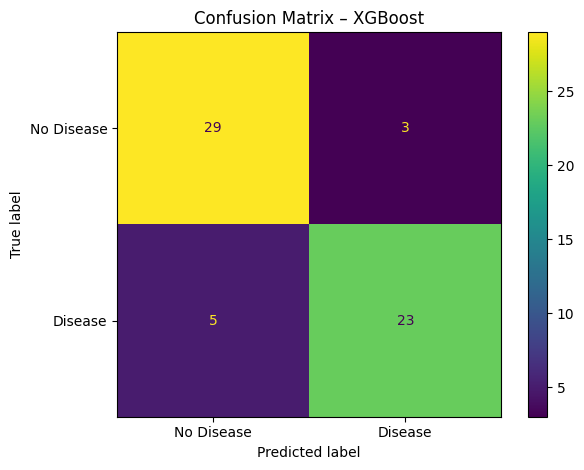

In [53]:
xgb_confusion_matrix = confusion_matrix(
    y_test,
    y_pred_xgb
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=xgb_confusion_matrix,
    display_labels=['No Disease', 'Disease']
)

disp.plot(values_format='d')

plt.title("Confusion Matrix – XGBoost")

plt.tight_layout()


plt.show()

### 8.4.4 ROC Curve

The ROC curve was generated to examine the discrimination performance of XGBoost across different classification thresholds.

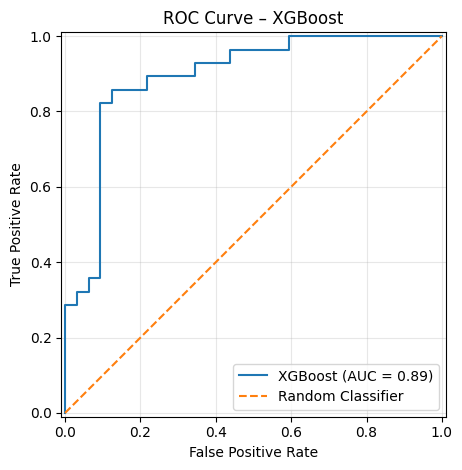

In [54]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name="XGBoost"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve – XGBoost")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### 8.4.5 Model Interpretation

XGBoost achieved an accuracy of **86.7%**, a precision of **88.5%**, a recall of **82.1%**, and an F1-score of **85.2%**. Its ROC-AUC score was **0.892**.

The confusion matrix showed 29 true negatives, three false positives, five false negatives, and 23 true positives.

Compared with the other evaluated models, XGBoost achieved the highest accuracy, precision, recall, and F1-score. Although its ROC-AUC was lower than those of Logistic Regression and Random Forest, it provided the strongest overall balance across the threshold-dependent evaluation metrics.

### Key Finding

XGBoost achieved the strongest threshold-dependent classification performance and produced the fewest false-negative predictions on the selected testing subset.

### Implication for Model Comparison

The final model selection should consider the combined pattern of results rather than a single evaluation metric. XGBoost provided the strongest threshold-dependent performance, whereas Logistic Regression achieved the highest ROC-AUC.

# 9. Model Comparison

## 9.1 Comparison of Evaluation Metrics

The predictive performance of Logistic Regression, Random Forest, and XGBoost was compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

All models were evaluated on the same testing dataset using identical evaluation metrics to ensure a fair comparison.

In [55]:
comparison_results = pd.concat(
    [
        lr_results,
        rf_results,
        xgb_results
    ],
    ignore_index=True
)

comparison_results.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.833,0.846,0.786,0.815,0.950
1,Random Forest,0.850,0.880,0.786,0.830,0.941
2,XGBoost,0.867,0.885,0.821,0.852,0.892


### Interpretation

All three machine learning models achieved competitive predictive performance on the same testing dataset.

XGBoost achieved the highest Accuracy, Precision, Recall, and F1-score, whereas Logistic Regression achieved the highest ROC-AUC score. Random Forest produced intermediate performance across most evaluation metrics.

These results indicate that each model exhibited different strengths depending on the evaluation criterion.

## 9.2 Performance Comparison Chart

A grouped bar chart was created to provide a visual comparison of the evaluation metrics across the three machine learning models.

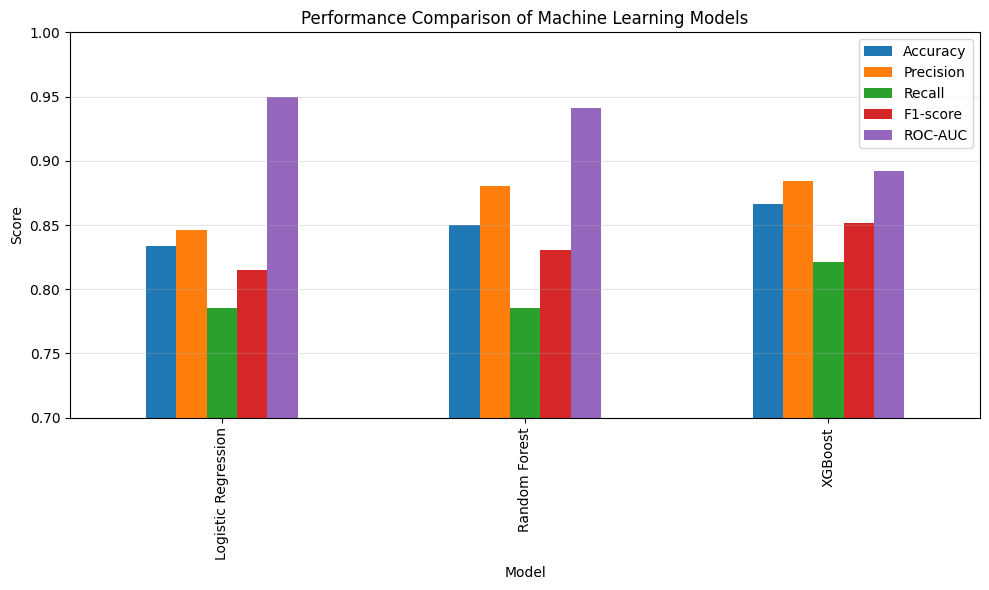

In [56]:
comparison_results.plot(
    x='Model',
    y=['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    kind='bar',
    figsize=(10,6)
)

plt.title("Performance Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.ylim(0.70,1.00)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation

The grouped bar chart confirms the numerical comparison presented in Table 4.3.

XGBoost achieved the highest scores for Accuracy, Precision, Recall, and F1-score, while Logistic Regression achieved the highest ROC-AUC score.

The chart further illustrates that no single model achieved the highest score across all evaluation metrics.

## 9.3 Model Selection

The objective of this study was not only to assess discrimination across classification thresholds but also to evaluate the overall balance of threshold-dependent classification performance.

Logistic Regression achieved the highest ROC-AUC score (**0.950**), indicating the strongest discrimination across different classification thresholds. However, XGBoost achieved the highest Accuracy, Precision, Recall, and F1-score at the default classification threshold of **0.5**.

XGBoost also produced the fewest false-negative predictions on the selected testing subset, with five false negatives compared with six for Logistic Regression and Random Forest.

Based on the overall evaluation, XGBoost was selected as the primary model for the local SHAP explanation and the supplementary evaluation.

This decision does not imply that XGBoost outperformed the other models according to every evaluation metric. Rather, it reflects the model-selection criteria adopted in this study while acknowledging the superior ROC-AUC performance of Logistic Regression.

## 9.4 Chapter Summary

This chapter compared the predictive performance of Logistic Regression, Random Forest, and XGBoost using the same testing dataset and evaluation metrics.

Logistic Regression achieved the highest ROC-AUC score, indicating the strongest discrimination across classification thresholds. In contrast, XGBoost achieved the highest Accuracy, Precision, Recall, and F1-score and produced the fewest false-negative predictions on the selected testing subset.

Based on the overall evaluation, XGBoost was selected for the subsequent local SHAP explanation and supplementary evaluation. The comparative findings presented in this chapter provide the basis for the explainability analyses presented in the next chapter.

# 10. SHAP Explainability

This section investigates model behaviour and feature contribution patterns using SHAP (SHapley Additive exPlanations).

Global SHAP analyses were performed for Logistic Regression, Random Forest, and XGBoost to compare their feature contribution patterns.

Because XGBoost achieved the strongest overall balance across the threshold-dependent evaluation metrics, it was additionally selected for a local SHAP explanation to illustrate how individual feature values contributed to a single correctly classified prediction.

## 10.1 Introduction to SHAP

SHAP is an explainable artificial intelligence method based on Shapley values from cooperative game theory. It assigns each feature a contribution value that represents how strongly the feature influences a model prediction.

Positive and negative SHAP values indicate whether a feature pushes the model output towards or away from the positive heart disease class. The magnitude of a SHAP value reflects the strength of the feature's contribution.

SHAP can provide both global explanations of overall model behaviour and local explanations of individual predictions.

## 10.2 SHAP Analysis Framework

Different SHAP explainers were used according to the structure of each machine learning model. A linear SHAP explainer was applied to Logistic Regression, whereas tree-based explainers were used for Random Forest and XGBoost.

Global SHAP analyses were conducted for all three models to identify and compare the features contributing most strongly to their predictions. Because SHAP values from different model families may be represented on different output scales, the comparison focuses on relative feature rankings rather than raw SHAP magnitudes.

A local SHAP explanation was additionally generated for the selected XGBoost model to illustrate how individual feature contributions combined to produce a single prediction.

## 10.3 Global Explainability Across Models

Global SHAP analyses were conducted separately for Logistic Regression, Random Forest, and XGBoost.

For each model, a SHAP summary plot was used to examine both feature importance and the direction of feature effects. A SHAP bar plot was then used to summarize the average absolute contribution of each feature across the testing dataset.

### 10.3.1 Logistic Regression

A SHAP linear explainer was applied to the trained Logistic Regression model.

Since Logistic Regression was trained using standardized features, SHAP values were calculated using the scaled training and testing datasets. The original feature values and feature names were retained in the visualizations to improve readability and interpretation.

#### Create SHAP Explainer

In [57]:
lr_masker = shap.maskers.Independent(
    X_train_scaled,
    max_samples=X_train_scaled.shape[0]
)

lr_explainer = shap.LinearExplainer(
    lr_model,
    lr_masker
)

lr_shap_raw = lr_explainer(
    X_test_scaled
)

lr_shap_values = shap.Explanation(
    values=lr_shap_raw.values,
    base_values=lr_shap_raw.base_values,
    data=X_test.to_numpy(),
    feature_names=X.columns.tolist()
)

#### SHAP Summary Plot

The SHAP summary plot was generated to examine the overall contribution of each feature to the Logistic Regression predictions.

Features are ordered according to their mean absolute SHAP values. Each point represents one patient, while the colour indicates the original feature value. Positive SHAP values push the model output towards the heart disease class, whereas negative SHAP values push it towards the no-disease class.

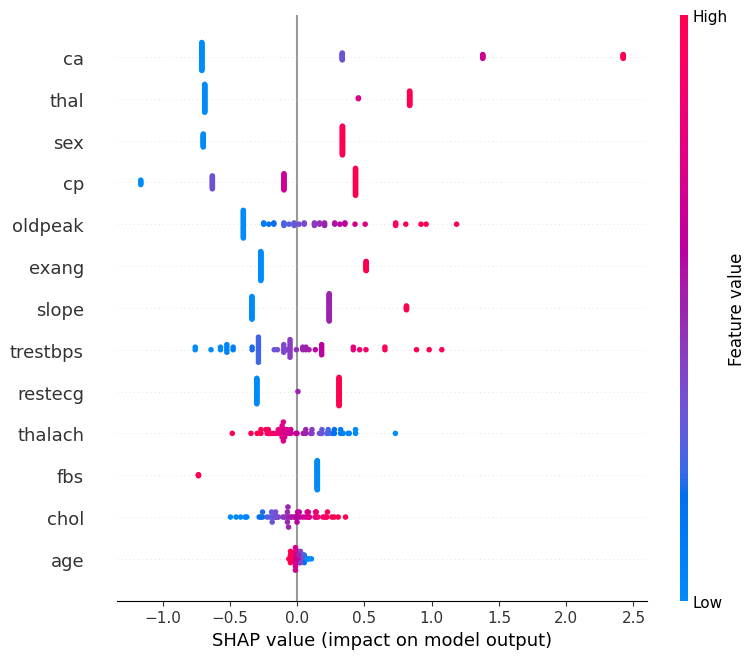

In [58]:
shap.summary_plot(
    lr_shap_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.show()

#### Interpretation

The SHAP summary plot indicates that **ca** and **thal** have the largest overall influence on the Logistic Regression predictions.

Higher values of **ca** and **thal** are mainly associated with positive SHAP values, pushing the model output towards the heart disease class, whereas lower values tend to support predictions of no heart disease.

Higher values of **oldpeak**, **exang**, **slope**, and **trestbps** also tend to increase the model output. In contrast, higher values of **thalach** generally shift the prediction towards the no-disease class.

Overall, the summary plot provides information about both the ranking of the features and the direction of their effects on the model predictions.

#### SHAP Feature Importance Bar Plot

The SHAP feature importance bar plot summarizes the average absolute contribution of each feature across all Logistic Regression predictions.

Unlike the SHAP summary plot, the bar plot displays only the magnitude of feature contributions and does not show whether individual feature values increase or decrease the model output.

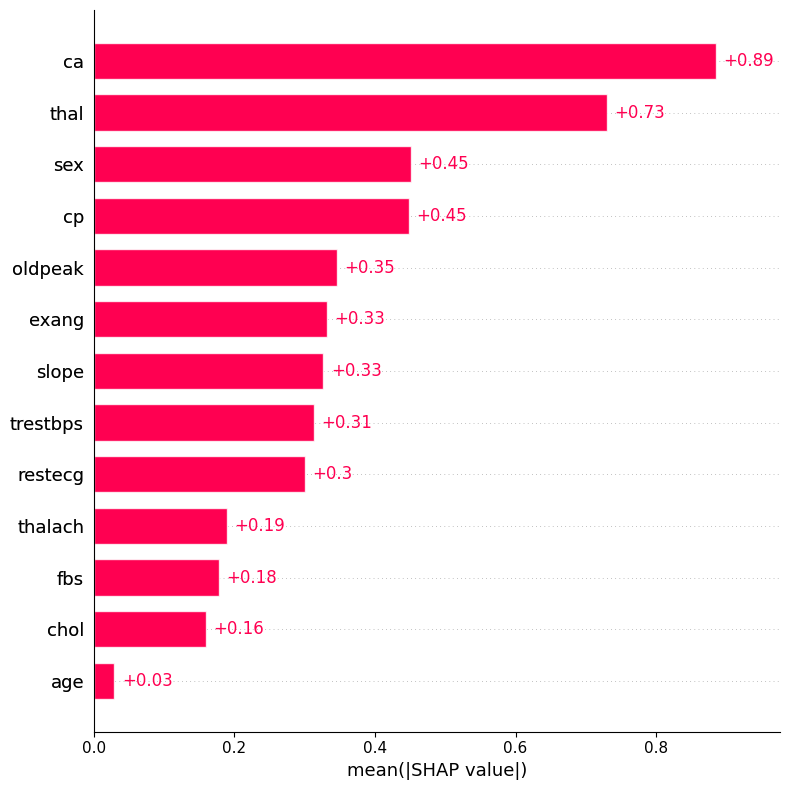

In [59]:
shap.plots.bar(
    lr_shap_values,
    max_display=13,
    show=False
)

plt.tight_layout()

plt.show()

#### Interpretation

The SHAP feature importance bar plot confirms the ranking observed in the SHAP summary plot.

Among all variables, **ca** and **thal** exhibit the highest average absolute SHAP values, followed by **sex** and **cp**.

The remaining variables contribute progressively less to the Logistic Regression predictions, while **age** has the smallest average SHAP value, indicating only a limited overall contribution.

Overall, the bar plot provides a simplified overview of global feature importance and confirms the consistency of the SHAP ranking observed in the summary plot.

### 10.3.2 Random Forest

A tree-based SHAP explainer was applied to the trained Random Forest model.

Since Random Forest was trained using the original unscaled features, SHAP values were calculated directly from the original testing dataset. The analysis focuses on the feature contributions associated with the positive heart disease class.

#### Create SHAP Explainer

In [60]:
rf_explainer = shap.TreeExplainer(
    rf_model
)

rf_shap_raw = rf_explainer(
    X_test
)

rf_shap_values = rf_shap_raw[:, :, 1]

#### SHAP Summary Plot

The SHAP summary plot was generated to investigate the overall contribution of each feature to the Random Forest predictions.

Features are ranked according to their mean absolute SHAP values. Each point represents one patient, while the colour indicates the original feature value. Positive SHAP values push the model output towards the heart disease class, whereas negative SHAP values push it towards the no-disease class.

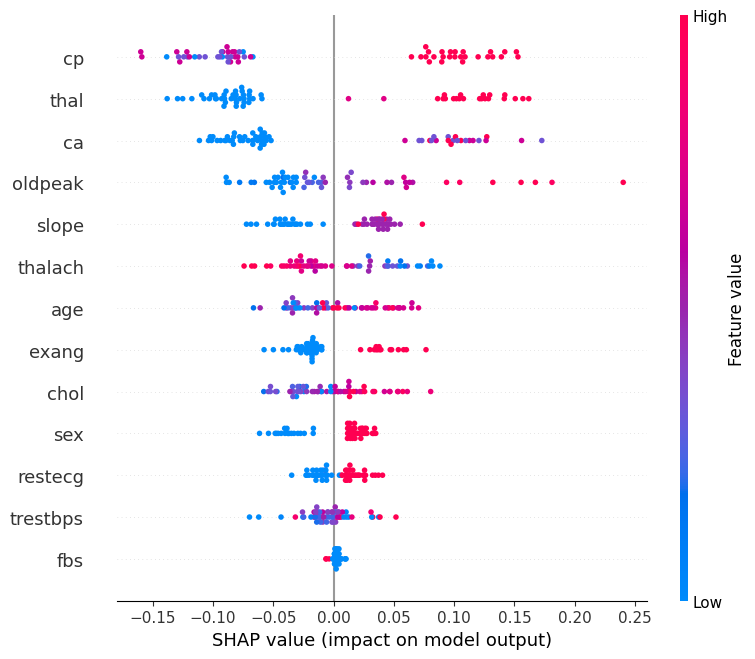

In [61]:
shap.summary_plot(
    rf_shap_values,
    X_test,
    show=False
)

plt.tight_layout()
plt.show()

#### Interpretation

The SHAP summary plot illustrates the overall feature contribution patterns of the Random Forest model across the testing dataset.

Among all variables, **cp**, **thal**, and **ca** exhibit the highest overall influence on the model predictions. These features consistently produce the largest SHAP values, indicating that they contribute most strongly to the prediction of heart disease.

Higher values of **thal**, **ca**, **oldpeak**, and **cp** generally shift the model output towards the heart disease class, whereas lower values tend to support predictions of no heart disease.

Similarly, higher values of **exang** and lower values of **thalach** are associated with an increased likelihood of heart disease.

In contrast, **fbs** contributes very little to the model predictions, with SHAP values remaining close to zero for most observations.

#### SHAP Feature Importance Bar Plot

The SHAP feature importance bar plot summarizes the average absolute contribution of each feature across all Random Forest predictions.

Unlike the SHAP summary plot, the bar plot displays only the magnitude of feature contributions and does not indicate whether individual feature values increase or decrease the model output.

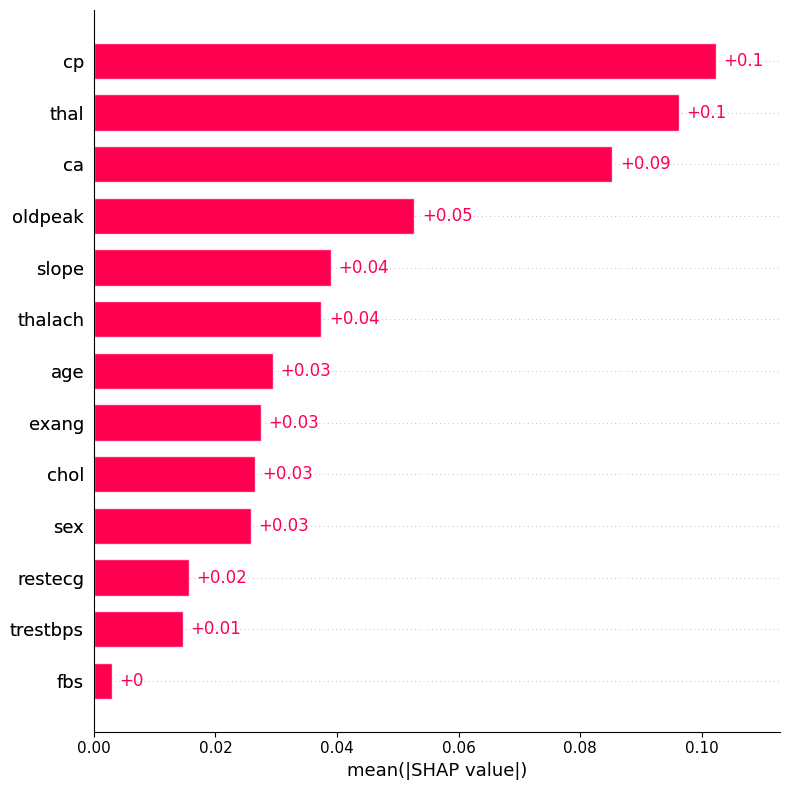

In [62]:
shap.plots.bar(
    rf_shap_values,
    max_display=13,
    show=False
)

plt.tight_layout()
plt.show()

#### Interpretation

The SHAP feature importance bar plot summarizes the mean absolute contribution of each feature across the Random Forest predictions.

Among all variables, **cp**, **thal**, and **ca** show the highest average absolute SHAP values, indicating that they make the largest overall contributions to the model predictions. These features are followed by **oldpeak** and **slope**, which also demonstrate notable global importance.

In contrast, **fbs** has the lowest average absolute SHAP value, suggesting that it contributes relatively little to the Random Forest predictions within the testing dataset.

Unlike the SHAP summary plot, the bar plot shows only the overall magnitude of feature contributions. It does not indicate whether higher or lower feature values increase or decrease the predicted model output.

### 10.3.3 XGBoost

A tree-based SHAP explainer was applied to the trained XGBoost model.

Since XGBoost was trained using the original unscaled features, SHAP values were calculated directly from the original testing dataset. The analysis focuses on the feature contributions associated with the positive heart disease class.

#### Create SHAP Explainer

In [63]:

xgb_explainer = shap.TreeExplainer(
    xgb_model
)

xgb_shap_values = xgb_explainer(
    X_test
)

#### SHAP Summary Plot

The SHAP summary plot was generated to investigate the overall contribution of each feature to the XGBoost predictions.

Features are ranked according to their mean absolute SHAP values. Each point represents one patient, while the colour indicates the original feature value. Positive SHAP values push the model output towards the heart disease class, whereas negative SHAP values push it towards the no-disease class.

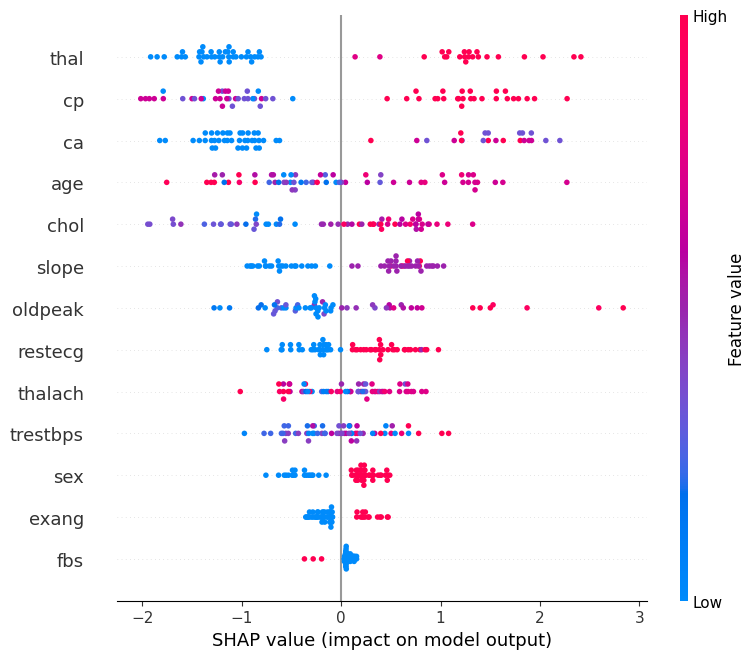

In [64]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    xgb_shap_values,
    X_test,
    show=False
)

plt.tight_layout()
plt.show()

#### Interpretation

The SHAP summary plot illustrates the overall feature contribution patterns of the XGBoost model across the testing dataset.

Among all variables, **thal**, **cp**, and **ca** exhibit the highest overall influence on the model predictions.

Higher values of **thal**, **ca**, and **oldpeak** generally shift the model output towards the heart disease class, whereas lower values tend to support predictions of no heart disease.

Features such as **age**, **chol**, and **slope** also contribute to the model predictions, although their overall influence is considerably smaller than that of the leading predictors.

Overall, the summary plot provides information about both the ranking of the features and the direction of their contributions to the XGBoost predictions.

#### SHAP Feature Importance Bar Plot

The SHAP feature importance bar plot summarizes the average absolute contribution of each feature across all XGBoost predictions.

Unlike the SHAP summary plot, the bar plot displays only the magnitude of feature contributions and does not indicate whether individual feature values increase or decrease the model output.

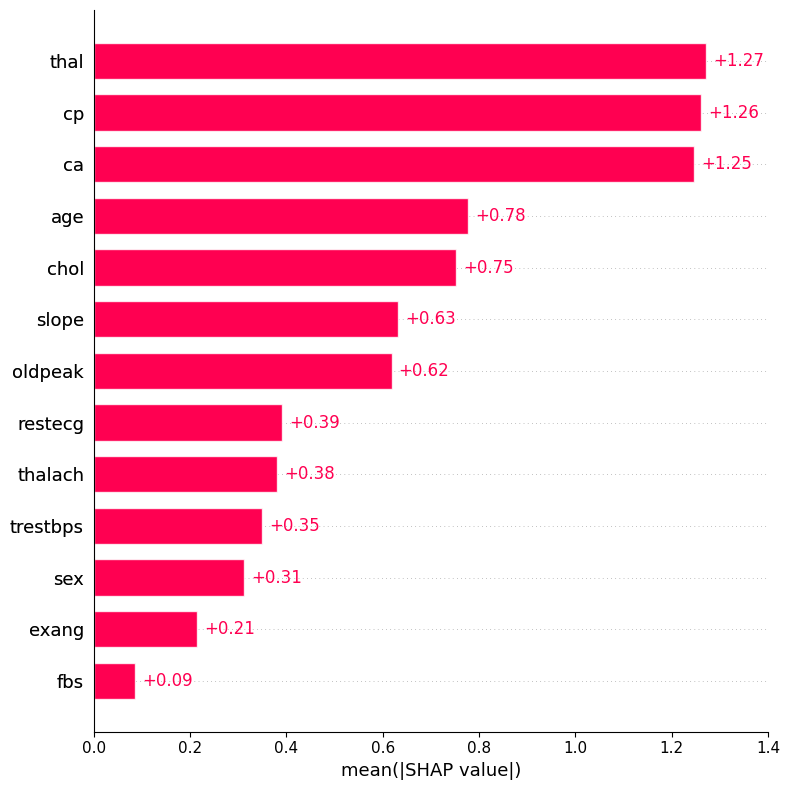

In [65]:
plt.figure(figsize=(8,6))

shap.plots.bar(
    xgb_shap_values,
    max_display=13,
    show=False
)

plt.tight_layout()

plt.show()

#### Interpretation

The SHAP feature importance bar plot confirms the ranking observed in the SHAP summary plot.

Among all variables, **thal**, **cp**, and **ca** have the highest average absolute SHAP values, indicating that these variables contribute most strongly to the XGBoost predictions.

Features such as **age**, **chol**, **slope**, and **oldpeak** also influence the model decisions, although their average contributions are considerably smaller than those of the three leading predictors.

The remaining variables contribute relatively little to the final predictions, while **fbs** exhibits the lowest average SHAP importance.

Overall, the bar plot provides a simplified overview of global feature importance and confirms the consistency of the SHAP ranking observed in the summary plot.

## 10.4 Comparison of SHAP Results Across Models

The previous sections presented separate SHAP analyses for Logistic Regression, Random Forest, and XGBoost.

Although each model was developed using a different learning algorithm, comparing their feature contribution patterns provides additional insight into whether the models rely on similar clinical variables when predicting heart disease.

To facilitate this comparison, the five highest-ranked features identified by each model are summarized in the table below.

In [66]:
# Calculate mean absolute SHAP values for each model
lr_mean_abs_shap = np.abs(
    lr_shap_values.values
).mean(axis=0)

rf_mean_abs_shap = np.abs(
    rf_shap_values.values
).mean(axis=0)

xgb_mean_abs_shap = np.abs(
    xgb_shap_values.values
).mean(axis=0)

# Extract the five highest-ranked features
lr_top_features = X.columns[
    np.argsort(lr_mean_abs_shap)[::-1][:5]
].tolist()

rf_top_features = X.columns[
    np.argsort(rf_mean_abs_shap)[::-1][:5]
].tolist()

xgb_top_features = X.columns[
    np.argsort(xgb_mean_abs_shap)[::-1][:5]
].tolist()

comparison_df = pd.DataFrame({
    "Rank": [1, 2, 3, 4, 5],
    "Logistic Regression": lr_top_features,
    "Random Forest": rf_top_features,
    "XGBoost": xgb_top_features
})

comparison_df

,Rank,Logistic Regression,Random Forest,XGBoost
0,1,ca,cp,thal
1,2,thal,thal,cp
2,3,sex,ca,ca
3,4,cp,oldpeak,age
4,5,oldpeak,slope,chol


### Interpretation

The comparison shows that the three machine learning models identify a broadly consistent set of influential predictors despite their different learning mechanisms.

Among all variables, **thal**, **cp**, and **ca** consistently appear among the highest-ranked features across the three models. This agreement suggests that these variables were consistently identified as influential predictors across the three machine learning models within the Cleveland Heart Disease Dataset.

Some differences are also observed. Logistic Regression assigns relatively higher importance to **sex**, whereas Random Forest emphasizes **oldpeak** and **slope**, and XGBoost gives greater importance to **age** and **chol**.

These differences are expected because each algorithm models the relationship between the input variables and the target outcome differently. Logistic Regression captures linear relationships, while Random Forest and XGBoost are capable of learning complex non-linear interactions among features.

Overall, the similarity in the highest-ranked predictors across the three models provides evidence of consistency in the feature contribution patterns observed within the Cleveland Heart Disease Dataset.

A detailed comparison between the findings of this study and the existing literature is presented in Chapter 5 (Discussion).

The comparison of the global SHAP analyses identified a consistent group of influential features across the three machine learning models.

To complement the global analyses, a local SHAP explanation was generated for the selected XGBoost model to illustrate how individual feature values contributed to one correctly classified prediction.

## 10.5 Local Explainability

While the previous analyses examined the overall behaviour of the three machine learning models, local explainability focuses on the prediction of an individual patient.

Because XGBoost achieved the strongest balance of threshold-dependent classification metrics on the selected test split, local SHAP analysis was performed using the selected XGBoost model.

A correctly classified positive case with a high predicted probability of heart disease was selected as an illustrative example for the local SHAP analysis. The waterfall plot was then used to illustrate how individual feature values contributed to the final prediction.

### 10.5.1 Illustrative Patient Selection

To avoid selecting an arbitrary observation, a correctly classified positive case was chosen from the testing dataset.

The selected patient had the highest predicted probability of heart disease among all correctly classified positive cases in the testing dataset.

In [67]:
patient_predictions = pd.DataFrame({
    'test_position': np.arange(len(y_test)),
    'original_index': X_test.index,
    'actual_class': y_test.to_numpy(),
    'predicted_class': y_pred_xgb,
    'predicted_probability': y_prob_xgb
})

correct_positive_cases = patient_predictions[
    (patient_predictions['actual_class'] == 1) &
    (patient_predictions['predicted_class'] == 1)
].sort_values(
    by='predicted_probability',
    ascending=False
)

selected_position = int(
    correct_positive_cases.iloc[0]['test_position']
)

selected_patient = correct_positive_cases.iloc[[0]]

selected_patient.round(4)

,test_position,original_index,actual_class,predicted_class,predicted_probability
41,41,203,1,1,0.9999


The selected observation corresponds to patient index **203** in the cleaned dataset.

The patient's actual class was heart disease, and the XGBoost model correctly predicted the same class with a probability of **0.9999**.

This observation was selected because it had the highest predicted probability among all correctly classified positive cases in the testing dataset.

This case was selected to provide a clear, reproducible, and interpretable example of the model's decision-making process rather than to represent the entire patient population.

### 10.5.2 SHAP Waterfall Plot

The SHAP waterfall plot explains how the individual feature values of the selected patient shifted the model output from its baseline value towards the final prediction.

Features with positive SHAP values increase the model output towards the heart disease class, whereas features with negative SHAP values decrease it.

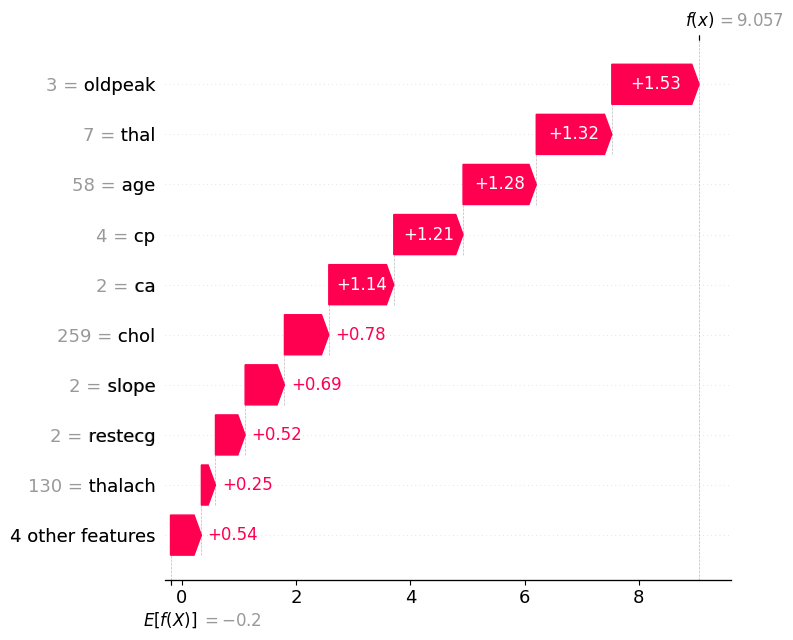

In [68]:
shap.plots.waterfall(
    xgb_shap_values[selected_position],
    max_display=10,
    show=False
)

plt.tight_layout()

plt.show()

### Interpretation

The SHAP waterfall plot explains how the XGBoost model reached its prediction for the selected patient.

Starting from the model's expected output, the contribution of each feature shifts the prediction towards the final model output.

For XGBoost, the waterfall plot presents the model output on the raw margin (log-odds) scale rather than directly as a probability. Therefore, the final value shown in the plot represents the raw model output, while the predicted probability for the positive heart disease class is obtained after applying the model's probability transformation. In this example, the final raw model output corresponds to a predicted probability of approximately **0.9999**, indicating a very high-confidence positive prediction.

For this patient, **oldpeak**, **thal**, **age**, **cp**, and **ca** made the largest positive contributions to the prediction. Other variables, including **chol**, **slope**, **restecg**, and **thalach**, also contributed to the model output but with smaller effects.

The ranking of the most influential features is broadly consistent with the global SHAP analyses, indicating that the variables identified as globally important also contribute substantially to this individual prediction.

Overall, the waterfall plot demonstrates how multiple clinical features combine to produce a confident prediction for a single patient, improving the transparency and interpretability of the XGBoost model.

The local explanation complements the global SHAP analyses by illustrating how the feature contribution patterns observed across the testing dataset are reflected in one correctly classified prediction.

## 10.6 Section Summary

This section investigated the explainability of the developed machine learning models using SHAP (SHapley Additive exPlanations).

Global SHAP analyses were performed for Logistic Regression, Random Forest, and XGBoost, enabling comparison of their feature contribution patterns. Despite differences in the underlying learning algorithms, **thal**, **cp**, and **ca** consistently appeared among the most influential predictors, although differences were observed in the ranking of the remaining features.

A local SHAP explanation was then generated for the selected XGBoost model to illustrate how individual feature values combined to produce a single prediction.

Overall, the SHAP analyses complemented the predictive performance evaluation by improving the transparency and interpretability of the developed machine learning models.

# 11. Supplementary Evaluation on the Statlog Heart Disease Dataset

> **Methodological Note**
>
> During the implementation phase, a record-level comparison was performed between the processed Cleveland dataset and the Statlog Heart Disease dataset. This comparison indicated that all 270 Statlog observations were also present in the processed Cleveland dataset used in this study.
>
> Consequently, the evaluation presented in this chapter should not be interpreted as an independent external validation. Instead, it is reported as a supplementary evaluation to provide a transparent assessment of the selected model on the Statlog Heart Disease dataset while acknowledging the relationship between the two datasets.

## 11.1 Introduction

Following the internal evaluation on the processed Cleveland Heart Disease dataset, the selected XGBoost model was further assessed using the Statlog Heart Disease dataset.

To ensure an appropriate interpretation of the evaluation results, a record-level comparison was performed after preprocessing to examine the relationship between the two datasets. The comparison demonstrated complete record-level overlap, indicating that all Statlog observations were already present in the processed Cleveland dataset used in this study.

Accordingly, the following analysis is presented as a supplementary evaluation rather than an independent external validation.

## 11.2 Load the Statlog Heart Disease Dataset

The Statlog Heart Disease dataset was loaded and prepared for the supplementary evaluation.

In [69]:
columns = [
    'age',
    'sex',
    'cp',
    'trestbps',
    'chol',
    'fbs',
    'restecg',
    'thalach',
    'exang',
    'oldpeak',
    'slope',
    'ca',
    'thal',
    'target'
]

statlog_df = pd.read_csv(
    "heart.dat",
    sep=r"\s+",
    header=None,
    names=columns
)

statlog_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,70.0,1.0,4.0,130.0,322.0,0.0,2.0,109.0,0.0,2.4,2.0,3.0,3.0,2
1,67.0,0.0,3.0,115.0,564.0,0.0,2.0,160.0,0.0,1.6,2.0,0.0,7.0,1
2,57.0,1.0,2.0,124.0,261.0,0.0,0.0,141.0,0.0,0.3,1.0,0.0,7.0,2
3,64.0,1.0,4.0,128.0,263.0,0.0,0.0,105.0,1.0,0.2,2.0,1.0,7.0,1
4,74.0,0.0,2.0,120.0,269.0,0.0,2.0,121.0,1.0,0.2,1.0,1.0,3.0,1


## 11.3 Data Inspection

The structure of Statlog dataset was examined to verify the number of observations, data types, and the presence of missing values before model evaluation.

In [70]:
statlog_df.shape

(270, 14)

In [71]:
statlog_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       270 non-null    float64
 1   sex       270 non-null    float64
 2   cp        270 non-null    float64
 3   trestbps  270 non-null    float64
 4   chol      270 non-null    float64
 5   fbs       270 non-null    float64
 6   restecg   270 non-null    float64
 7   thalach   270 non-null    float64
 8   exang     270 non-null    float64
 9   oldpeak   270 non-null    float64
 10  slope     270 non-null    float64
 11  ca        270 non-null    float64
 12  thal      270 non-null    float64
 13  target    270 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 29.7 KB


In [72]:
statlog_df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


The Statlog dataset contains 270 patient records and 14 variables, including 13 clinical features and one target variable.

No missing values were detected; therefore, no missing value handling was required before the supplementary evaluation.

## 11.4 Data Preprocessing

Before evaluating the trained model, the Statlog dataset was prepared using the same preprocessing approach applied to the Cleveland dataset.

The target variable was converted into a binary format, and the feature matrix and target vector were separated.

In [73]:
statlog_df['target'].value_counts()

,count
target,
1,150
2,120


In [74]:
statlog_df['target'] = statlog_df['target'] - 1

In [75]:
statlog_df['target'].value_counts()

,count
target,
0,150
1,120


In [76]:
X_statlog = statlog_df.drop(columns='target')

y_statlog = statlog_df['target']

In [77]:
X_statlog.shape

(270, 13)

In [78]:
y_statlog.shape

(270,)

The target variable was converted into a binary format to match the class encoding used during model development on the Cleveland dataset.

The dataset was then separated into the feature matrix (X) and the target vector (y), resulting in 13 predictor variables and one binary target variable.

## 11.5 Record-Level Overlap Verification

 Before interpreting the results of the additional model evaluation, a record-level comparison was performed between the processed Cleveland Heart Disease dataset and the preprocessed Statlog Heart Disease dataset.

The purpose of this comparison was to determine whether the Statlog observations represented an independent set of patient records or were already contained within the processed Cleveland dataset used for model development.

To ensure a consistent comparison, the columns of both datasets were arranged in the same order. Each complete observation, including the 13 predictor variables and the binary target variable, was then compared across the two datasets.


In [79]:
# Create copies to avoid modifying the original datasets
cleveland_check = df.copy().reset_index(drop=True)
statlog_check = statlog_df.copy().reset_index(drop=True)

# Arrange the columns in the same order
statlog_check = statlog_check[cleveland_check.columns]

# Convert each complete observation into a tuple
cleveland_records = set(
    map(tuple, cleveland_check.to_numpy())
)

statlog_records = list(
    map(tuple, statlog_check.to_numpy())
)

# Identify Statlog observations present in the Cleveland dataset
matching_records = sum(
    record in cleveland_records
    for record in statlog_records
)

overlap_percentage = (
    matching_records / len(statlog_records)
) * 100

print(
    f"Matching Statlog observations: "
    f"{matching_records}/{len(statlog_records)}"
)

print(
    f"Record-level overlap: "
    f"{overlap_percentage:.1f}%"
)

if matching_records == len(statlog_records):
    print(
        "Complete record-level overlap detected."
    )
else:
    print(
        "Complete record-level overlap was not detected."
    )

Matching Statlog observations: 270/270
Record-level overlap: 100.0%
Complete record-level overlap detected.


**Result**

The record-level comparison showed that all 270 observations in the Statlog Heart Disease dataset were also present in the processed Cleveland Heart Disease dataset, corresponding to a record-level overlap of 100%.

Therefore, the Statlog dataset cannot be considered an independent external validation dataset in the context of this study. The following model evaluation is consequently presented as a supplementary evaluation on a closely related dataset rather than as evidence of independent external generalizability.


## 11.6 Supplementary Model Evaluation


The XGBoost model previously trained on the Cleveland dataset was evaluated directly on the Statlog Heart Disease dataset.

The model was not retrained or adjusted using the Statlog data. The evaluation was performed to compare the model's behaviour on this closely related dataset using the same evaluation procedure applied to the Cleveland testing dataset.

In [80]:
X_statlog = X_statlog[X.columns]

In [81]:
y_pred_statlog = xgb_model.predict(X_statlog)

y_prob_statlog = xgb_model.predict_proba(
    X_statlog
)[:, 1]

### 11.6.1 Performance Metrics

The predictive performance of the selected XGBoost model was evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

The same evaluation metrics used for the Cleveland testing dataset were applied to maintain consistency between the Cleveland testing dataset and the supplementary evaluation.

In [82]:
statlog_accuracy = accuracy_score(
    y_statlog,
    y_pred_statlog
)

statlog_precision = precision_score(
    y_statlog,
    y_pred_statlog
)

statlog_recall = recall_score(
    y_statlog,
    y_pred_statlog
)

statlog_f1 = f1_score(
    y_statlog,
    y_pred_statlog
)

statlog_roc_auc = roc_auc_score(
    y_statlog,
    y_prob_statlog
)

In [83]:
statlog_results = pd.DataFrame({
    'Dataset': ['Statlog Supplementary Evaluation'],
    'Accuracy': [statlog_accuracy],
    'Precision': [statlog_precision],
    'Recall': [statlog_recall],
    'F1-score': [statlog_f1],
    'ROC-AUC': [statlog_roc_auc]
})

statlog_results.round(3)

,Dataset,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Statlog Supplementary Evaluation,0.974,0.975,0.967,0.971,0.984


### 11.6.2 Confusion Matrix

A confusion matrix was generated to examine the correct and incorrect predictions produced by the XGBoost model on the Statlog Heart Disease dataset.

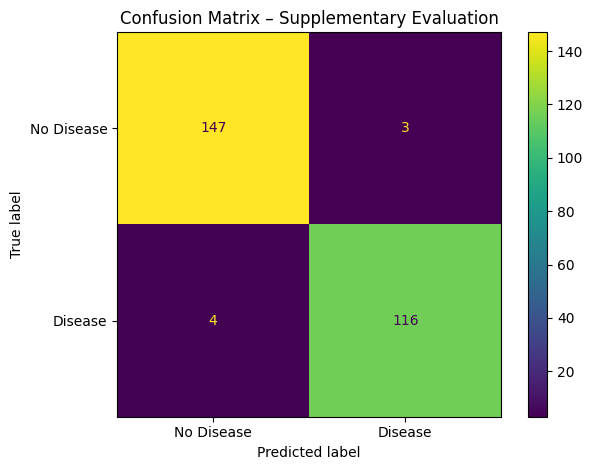

In [84]:
statlog_confusion_matrix = confusion_matrix(
    y_statlog,
    y_pred_statlog
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=statlog_confusion_matrix,
    display_labels=['No Disease', 'Disease']
)

disp.plot(values_format='d')

plt.title(
    'Confusion Matrix – Supplementary Evaluation'
)

plt.tight_layout()

plt.show()

### 11.6.3 ROC Curve

The ROC curve was generated to evaluate the model's ability to distinguish between patients with and without heart disease in Statlog dataset across different classification thresholds.

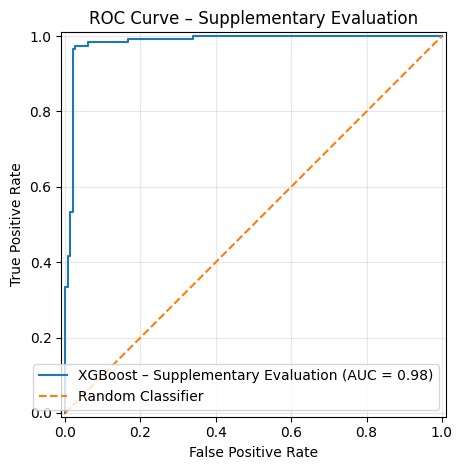

In [85]:
RocCurveDisplay.from_predictions(
    y_statlog,
    y_prob_statlog,
    name='XGBoost – Supplementary Evaluation'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.title(
    'ROC Curve – Supplementary Evaluation'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### 11.6.4 Interpretation

The supplementary evaluation demonstrated excellent predictive performance on the Statlog Heart Disease dataset.

The XGBoost model correctly classified **263 of the 270** observations, corresponding to an accuracy of **97.4%**. Only three patients without heart disease were incorrectly classified as positive, whereas four patients with heart disease were incorrectly classified as negative.

The ROC-AUC score of **0.984** indicates strong discrimination between the two classes within this dataset.

However, because the record-level comparison demonstrated complete overlap between the Statlog and processed Cleveland datasets, these results should not be interpreted as evidence of independent external model generalisability. Instead, they demonstrate that the trained model produced highly consistent predictions on a closely related dataset evaluated using the same procedure.

## 11.7 Comparison with Cleveland Results

To compare the predictive performance of the selected XGBoost model across the two evaluation settings, the results obtained on the Cleveland testing dataset were compared with those obtained during the additional evaluation on the Statlog Heart Disease dataset.

In [86]:
comparison_results = pd.DataFrame({

    'Dataset': [
        'Cleveland Test Set',
        'Statlog Supplementary Evaluation'
    ],

    'Accuracy': [
        0.867,
        0.974
    ],

    'Precision': [
        0.885,
        0.975
    ],

    'Recall': [
        0.821,
        0.967
    ],

    'F1-score': [
        0.852,
        0.971
    ],

    'ROC-AUC': [
        0.892,
        0.984
    ]

})

comparison_results

,Dataset,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Cleveland Test Set,0.867,0.885,0.821,0.852,0.892
1,Statlog Supplementary Evaluation,0.974,0.975,0.967,0.971,0.984


The supplementary evaluation produced consistently stronger predictive performance than the Cleveland testing dataset.

However, because complete record-level overlap was identified, these differences should not be interpreted as evidence of improved model generalisability to an independent patient cohort.

Instead, the comparison demonstrates that the trained XGBoost model produced highly consistent predictions on a closely related dataset evaluated using the same procedure.

## 11.8 Chapter Summary

This chapter presented a supplementary evaluation of the selected XGBoost model using the Statlog Heart Disease dataset.

The evaluation demonstrated strong predictive performance, while the record-level comparison confirmed complete overlap between the processed Cleveland and Statlog datasets.

Consequently, the Statlog evaluation should not be interpreted as independent external validation. Instead, it provides a transparent supplementary assessment of the selected model on a closely related dataset while explicitly acknowledging the relationship between the two datasets.